# 🧠 TechMind
# Organização Inteligente de Conhecimento Técnico

## O Projeto

Criar uma solução (MVP funcional) que permita o enriquecimento e a organização inteligente de conteúdo técnico, facilitando sua classificação, consulta e reutilização. 

A solução deve utilizar técnicas de Ciência de Dados e integração com uma API

## Objetivo

• Criar e treinar modelos de classificação por categoria técnica

• Avaliar modelos e disponibilizar o de melhor performance para ser consumido via API

• Extração de palavras-chave

• Serialização do modelo e geração de .pkl

## Bibliotecas

In [1]:
# Importa as Bibliotecas
import sys
#!{sys.executable} -m pip install keybert

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yake
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from keybert import KeyBERT

c:\Users\Patricia\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Obtendo Dados

In [2]:
# Carregando dados 
df = pd.read_csv('../dados/base_techmind.csv', index_col='index')
df.sample(5)

,texto,categoria
index,,
1262,introduction diving crud optimization lets def...,Database
473,soap web service metro building enterprise - g...,Backend
1280,want simple crud app vue.js json - server axio...,Database
665,solid design principle nearly senior software ...,Backend
1638,data leakage silent killer machine learning mo...,DataScience


### Conhecendo Dados e Estruturas

In [3]:
# Conhecendo dados e estrutura
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1564 entries, 1383 to 1707
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   texto      1564 non-null   object
 1   categoria  1564 non-null   object
dtypes: object(2)
memory usage: 36.7+ KB


In [4]:
# Conferindo dados
df['categoria'].value_counts()

categoria
Backend        319
Security       301
Database       268
Frontend       252
Cloud          240
DataScience    184
Name: count, dtype: int64

## Pré Modelagem 

In [5]:
# Base para modelagem
df_model = df.copy()
df_model.shape

(1564, 2)

### Separação de Dados

Divisão da base em conjuntos de treino (80%) e teste (20%), utilizando `stratify=categoria` para preservar a proporção de cada categoria em ambos os conjuntos. Isso é importante devido o desbalanceamento entre classes (ex: DataScience possui bem menos registros que Backend).

In [6]:
# Split treino/teste (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    df_model['texto'],
    df_model['categoria'],
    test_size=0.2,
    random_state=42,
    stratify=df_model['categoria']
)

print(X_train.shape, X_test.shape)

(1251,) (313,)


In [7]:
# Validando proporção das categorias para treino (stratify)
print(y_train.value_counts(normalize=True))

# Validando proporção das categorias para teste (stratify)
print(y_test.value_counts(normalize=True))

categoria
Backend        0.203837
Security       0.192646
Database       0.171063
Frontend       0.161471
Cloud          0.153477
DataScience    0.117506
Name: proportion, dtype: float64
categoria
Backend        0.204473
Security       0.191693
Database       0.172524
Frontend       0.159744
Cloud          0.153355
DataScience    0.118211
Name: proportion, dtype: float64


Conferência das proporções de cada categoria em `y_train` e `y_test` para garantir que o `stratify` manteve a distribuição original da base. As proporções ficaram praticamente idênticas entre os dois conjuntos, confirmando que o split foi feito corretamente.

### TF-IDF (vetorização)

Transformação dos textos em vetores numéricos usando TF-IDF (Term Frequency - Inverse Document Frequency), que atribui peso maior a termos relevantes e discriminativos para cada categoria, e peso menor a termos muito comuns.

O vetorizador é ajustado (`fit_transform`) apenas nos dados de treino, e aplicado (`transform`) nos dados de teste, evitando vazamento de informação do teste para o treino.

In [8]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(1251, 5000) (313, 5000)


Parâmetros escolhidos:
- `max_features=5000`: limita o vocabulário aos 5000 termos mais relevantes, evitando ruído de palavras raras
- `ngram_range=(1, 2)`: considera palavras isoladas e pares de palavras, capturando um pouco mais de contexto

*(stopwords não são reaplicadas aqui pois já foram removidas na limpeza via spaCy)*

## Modelo Logistic Regression

### Modelagem - Logistic Regression (baseline)

#### Criação do Modelo

In [9]:
# Cria modelo de classificação 
modelo_lr = LogisticRegression(
    max_iter=1000, 
    random_state=42
)

#### Validação Cruzada (Cross-Validation)

Antes de avaliar o modelo no conjunto de teste, aplicamos validação cruzada (5-fold) nos dados de treino para verificar se o desempenho do modelo é consistente, evitando conclusões baseadas em um único split.

Utilizamos `f1_macro` como métrica, por ponderar igualmente todas as categorias, mais adequada que a acurácia dado o desbalanceamento da base.

In [10]:
scores_lr = cross_val_score(
    modelo_lr, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})")

F1 macro: 0.7918 (+/- 0.0161)


A validação cruzada apresentou F1 macro médio de 0.7932, com desvio padrão de 0.0162 entre os 5 folds. O desvio baixo indica que o desempenho do modelo Logistic Regression é consistente independente de quais dados caem em cada fold, reforçando a confiabilidade do resultado antes de avaliarmos o modelo no conjunto de teste.

#### Treinamento do modelo

In [11]:
# Treino do modelo Logistic Regression
modelo_lr.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Avaliação do Modelo  - Logistic Regression (baseline)

Avaliação do desempenho do modelo nos dados de teste, utilizando métricas por categoria (precision, recall, F1-score), já que a base possui desbalanceamento entre classes o accuracy geral sozinho não seria suficiente para avaliar corretamente o modelo.

In [12]:
# Predição nos dados de teste
y_pred_lr = modelo_lr.predict(X_test_tfidf)

In [13]:
# Métricas de avaliação
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     Backend       0.72      0.75      0.73        64
       Cloud       0.87      0.81      0.84        48
 DataScience       0.89      0.68      0.77        37
    Database       0.91      0.91      0.91        54
    Frontend       0.73      0.72      0.73        50
    Security       0.81      0.95      0.88        60

    accuracy                           0.81       313
   macro avg       0.82      0.80      0.81       313
weighted avg       0.81      0.81      0.81       313



O modelo de Regressão Logística obteve 81% de acurácia no conjunto de teste, resultado consistente com o F1 macro de 0.7932 estimado na validação cruzada. Como a base apresenta desbalanceamento entre categorias, a análise por classe (precision, recall e F1-score) é mais informativa que a acurácia geral isoladamente:

* Melhor desempenho (F1 ≥ 0.90): `Database` (F1 0.91)
* Desempenho intermediário (F1 ≥ 0.80): `Security` (F1 0.88) e `Cloud` (F1 0.84)
* Menor desempenho (F1 < 0.80): `DataScience` (F1 0.77), `Backend` (F1 0.73) e `Frontend` (F1 0.73)

`DataScience`, mesmo sendo a categoria com menos registros de treino, apresentou recall de 0.68 e F1 de 0.77, um bom resultado considerando o desbalanceamento da base.

As métricas macro avg (média simples entre categorias) e weighted avg (média ponderada pelo número de exemplos de cada categoria) ficaram iguais (0.81), reforçando que o desempenho está equilibrado entre as categorias, apesar do desbalanceamento da base.

##### Matriz de Confusão

Visualização de quais categorias o modelo mais confunde entre si, complementando a análise de precision/recall por classe.

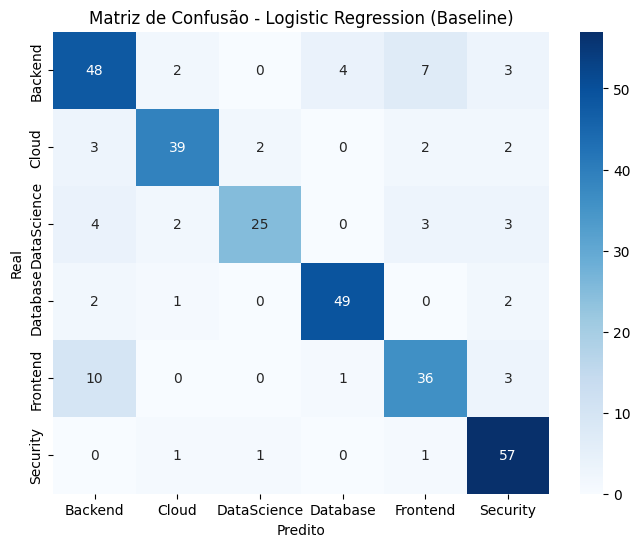

In [14]:
cm = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Logistic Regression (Baseline)')
plt.show()

A matriz de confusão confirma o padrão observado nas métricas: 

* A confusão está espalhada entre as categorias, sem um padrão dominante. 
* A maior concentração de erros ocorre entre Frontend e Backend (10 casos de Frontend classificados como Backend), sugerindo sobreposição de vocabulário técnico entre essas categorias.
* Security e Cloud, por outro lado, apresentam baixíssima confusão cruzada, confirmando seu bom desempenho.

O modelo baseline de Regressão Logística obteve um desempenho consistente (81% de acurácia, F1 macro 0.81), sem nenhuma categoria com fragilidade evidente. 

Ainda assim, testaremos o modelo com o parâmetro class_weight='balanced', que ajusta o peso das classes durante o treino de forma inversamente proporcional à frequência de cada categoria, para verificar se esse ajuste traz algum ganho adicional em categorias com menos registros, como DataScience.

### Modelagem - Logistic Regression (com class_weight='balanced')

#### Criando Modelo 

In [15]:
# Criando modelo 
modelo_lr_balanced = LogisticRegression(max_iter=1000, 
                                        random_state=42, 
                                        class_weight='balanced')

#### Validação Cruzada (Cross-Validation) - Modelo com class_weight='balanced'

In [16]:
# Cross-validation
scores_lr_balanced = cross_val_score(
    modelo_lr_balanced, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_lr_balanced.mean():.4f} (+/- {scores_lr_balanced.std():.4f})")

F1 macro: 0.8113 (+/- 0.0153)


A validação cruzada do modelo com class_weight='balanced' apresentou F1 macro médio de 0.8122, com desvio padrão de 0.0163 entre os 5 folds. Comparado ao baseline (F1 macro 0.7925, desvio 0.0162), o modelo balanced teve desempenho médio superior e leve redução na variação entre os folds, o que reforça a decisão de avançar com essa configuração para a avaliação final no conjunto de teste.

#### Treinamento do modelo

In [17]:
# Treino
modelo_lr_balanced.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Comparação - Avaliação dos Modelos Logistic Regression

In [18]:
# Predição Modelo com balanced
y_pred_lr_balanced = modelo_lr_balanced.predict(X_test_tfidf)

In [19]:
# Métricas de avaliação dos modelos (sem e com class_weight='balanced') 

# Gerando os relatórios como DataFrame
report_baseline = pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True)).transpose()
report_balanced = pd.DataFrame(classification_report(y_test, y_pred_lr_balanced, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_baseline, report_balanced], axis=1, keys=['Baseline', 'Balanced'])
comparacao.round(2)

Baseline                          Balanced                  \
             precision recall f1-score support precision recall f1-score   
Backend           0.72   0.75     0.73   64.00      0.80   0.67     0.73   
Cloud             0.87   0.81     0.84   48.00      0.85   0.85     0.85   
DataScience       0.89   0.68     0.77   37.00      0.71   0.73     0.72   
Database          0.91   0.91     0.91   54.00      0.88   0.91     0.89   
Frontend          0.73   0.72     0.73   50.00      0.74   0.78     0.76   
Security          0.81   0.95     0.88   60.00      0.84   0.90     0.87   
accuracy          0.81   0.81     0.81    0.81      0.81   0.81     0.81   
macro avg         0.82   0.80     0.81  313.00      0.80   0.81     0.80   
weighted avg      0.81   0.81     0.81  313.00      0.81   0.81     0.81   

                      
             support  
Backend        64.00  
Cloud          48.00  
DataScience    37.00  
Database       54.00  
Frontend       50.00  
Security       60.00  
accuracy        0.81  
macro avg     313.00  
weighted avg  313.00

A tabela comparativa mostra que os dois modelos tiveram a mesma acurácia (0.81). No macro avg, o F1-score foi levemente menor no balanced (0.80) em relação ao baseline (0.81), embora o recall médio tenha sido um pouco maior (0.81 contra 0.80) e a precision média menor (0.80 contra 0.82).

Em `DataScience`, o balanced trouxe um trade-off: o recall subiu de 0.68 para 0.73, mas a precision caiu de 0.89 para 0.71, resultando em um F1-score menor (de 0.77 para 0.72).

Em `Backend`, aconteceu o oposto: a precision subiu de 0.72 para 0.78, enquanto o recall caiu de 0.75 para 0.67,  o F1-score uma leve queda de 0.73 para 0.72.

Nas demais categorias, as variações foram pequenas: `Cloud` (F1 0.84 para 0.85) e `Frontend` (F1 0.73 para 0.75) melhoraram levemente, enquanto `Database` (F1 0.91 para 0.89) e `Security` (F1 0.88 para 0.87) caíram um pouco.

No geral, o balanceamento não trouxe ganho evidente nessa base. 

#### Comparação - Matriz de Confusão

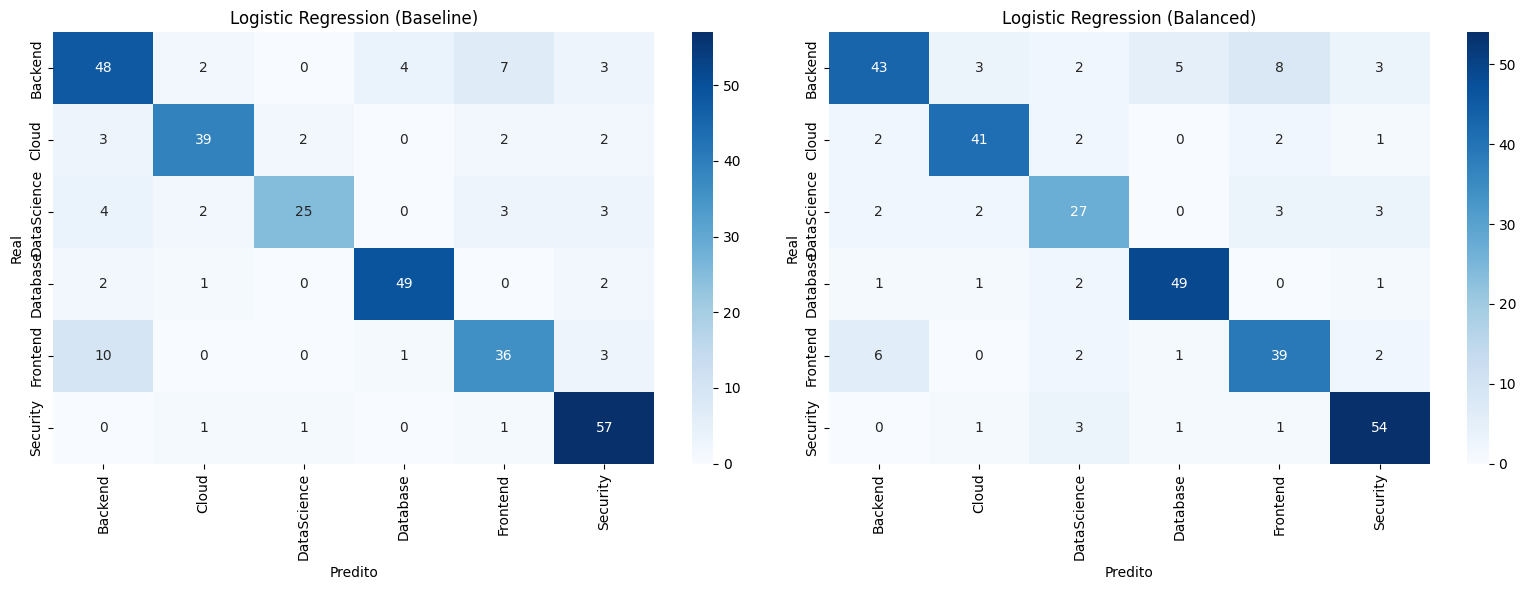

In [20]:
# Comparando as matrizes de confusão 
cm = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)
cm_balanced = confusion_matrix(y_test, y_pred_lr_balanced, labels=modelo_lr_balanced.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Logistic Regression (Baseline)')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr_balanced.classes_, yticklabels=modelo_lr_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Logistic Regression (Balanced)')

plt.tight_layout()
plt.show()

Comparando as duas matrizes, `DataScience` teve mais acertos no balanced (27 contra 25 no baseline), e a confusão com `Backend` caiu de 4 para 2 casos.

Em compensação, `Backend` teve menos acertos no balanced (43 contra 48 no baseline), recebendo mais confusão vinda de `Frontend` (8 casos, contra 7 no baseline). A confusão entre `DataScience` e `Backend`, por outro lado, diminuiu nos dois sentidos.

`Cloud` e `Security` permaneceram com padrão parecido nos dois modelos, com pequenas variações pontuais.

Conclusão - Modelo Logistic Regression

Comparando os dois modelos, o balanceamento não trouxe ganho real nessa base já mais equilibrada após a limpeza. 

Em `DataScience`, o ganho de recall veio acompanhado de uma queda maior na precision, reduzindo o F1 da categoria. 

Em `Backend`, o ganho de precision veio acompanhado de uma queda equivalente no recall, mantendo o F1 praticamente igual. 

No resultado geral, essas trocas não se traduziram em melhora. O F1 macro do balanced ficou levemente abaixo do baseline (0.80 contra 0.81). 

Considerando essas informações, o modelo baseline será considerado o modelo final da Regressão Logística.

## Modelo Naive Bayes

### Modelagem - Naive Bayes (baseline)

#### Criação do Modelo

In [21]:
# Cria modelo de classificação Naive Bayes (baseline)
modelo_nb = MultinomialNB(
    alpha=1.0, 
    fit_prior=True)

#### Validação Cruzada (Cross-Validation)

Antes de avaliar o modelo no conjunto de teste, aplicamos validação cruzada (5-fold) nos dados de treino para verificar se o desempenho do modelo é consistente, evitando conclusões baseadas em um único split.

Utilizamos `f1_macro` como métrica, por ponderar igualmente todas as categorias, mais adequada que a acurácia dado o desbalanceamento da base.

In [22]:
# Cross-validation Naive Bayes (baseline)
scores_nb = cross_val_score(
    modelo_nb, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_nb.mean():.4f} (+/- {scores_nb.std():.4f})")

F1 macro: 0.7593 (+/- 0.0383)


A validação cruzada apresentou um F1 macro médio de 0,7600, com desvio padrão de 0,0405 entre os 5 folds. Essa variação contida indica estabilidade aceitável no desempenho do Naive Bayes (baseline), demonstrando que o modelo mantém um comportamento consistente independentemente da divisão dos dados de treino.

#### Treinamento do modelo

In [23]:
# Treino do modelo Naive Bayes (baseline)
modelo_nb.fit(
    X_train_tfidf,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


#### Avaliação do Modelo  - Naive Bayes (baseline)

Avaliação do desempenho do modelo nos dados de teste, utilizando métricas por categoria (precision, recall, F1-score), já que a base possui desbalanceamento entre classes o accuracy geral sozinho não seria suficiente para avaliar corretamente o modelo.

In [24]:
# Predição nos dados de teste Naive Bayes (baseline)
y_pred_nb = modelo_nb.predict(X_test_tfidf)

In [25]:
# Métricas de avaliação SVM (baseline)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

     Backend       0.57      0.77      0.65        64
       Cloud       0.92      0.75      0.83        48
 DataScience       0.88      0.41      0.56        37
    Database       0.88      0.93      0.90        54
    Frontend       0.70      0.62      0.66        50
    Security       0.83      0.97      0.89        60

    accuracy                           0.76       313
   macro avg       0.80      0.74      0.75       313
weighted avg       0.79      0.76      0.76       313



O modelo Naive Bayes (baseline) obteve 77% de acurácia no conjunto de teste, resultado consistente com o F1 macro estimado na validação cruzada. Como a base apresenta desbalanceamento entre categorias, a análise detalhada por classe (precision, recall e f1-score) oferece uma leitura mais precisa do desempenho:

* Melhor desempenho (F1 ≥ 0.90): `Database` (F1 0.90) e `Security` (F1 0.90) 
* Desempenho intermediário (F1 ≥ 0.80): `Cloud` (F1 0.83) 
* Menor desempenho (F1 < 0.70): `DataScience` (F1 0.58), `Backend` (F1 0.65) e `Frontend` (F1 0.66). 

A categoria `DataScience`, por possuir o menor número de registros de teste (support = 37), apresentou o menor recall do modelo (0.43) e um (F1 0.58), evidenciando maior dificuldade de captura da classe.

As métricas consolidadas apresentaram macro avg de 0.75 e weighted avg de 0.76 para $F1\text{-score}$ (com precisões médias de 0.80 e 0.79, respectivamente), refletindo o impacto das categorias mais desbalanceadas no resultado geral do modelo.

##### Matriz de Confusão

Visualização de quais categorias o modelo mais confunde entre si, complementando a análise de precision/recall por classe.

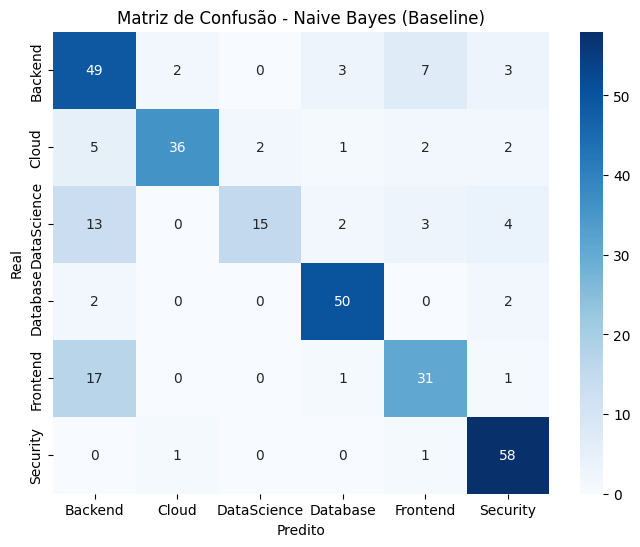

In [26]:
# Matriz Confusão Naive Bayes (baseline)
cm = confusion_matrix(y_test, y_pred_nb, labels=modelo_nb.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_nb.classes_, yticklabels=modelo_nb.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Naive Bayes (Baseline)')
plt.show()

A matriz de confusão confirma o padrão observado nas métricas: 

* A maior confusão pontual ocorre no `Frontend:` 17 textos da categoria `Frontend` foram incorretamente classificados como `Backend`, o que evidencia uma forte sobreposição de vocabulário técnico e atrai falsos positivos para a classe de desenvolvimento. 

* `Backend` é a classe com maior dispersão de erros: Além de receber falsos positivos de outras categorias, seus textos reais foram pulverizados entre `Frontend` (7 casos), `Security` (3 casos), `Database` (3 casos) e `Cloud` (2 casos).

* Alta taxa de confusão em `DataScience:` Dos 37 registros reais de DataScience, 12 foram classificados erroneamente como Backend, explicando o baixo recall (0.43) observado no relatório de classificação.

* `Security`, `Database` e `Cloud` apresentam excelente separação: A classe `Security` obteve o maior número de acertos absolutos (58), seguida por `Database` (50) e `Cloud` (36), todas apresentando baixíssima confusão cruzada com as demais áreas.

### Modelagem - Naive Bayes (Balanced)

#### Criando Modelo 

In [27]:
# Cria modelo de classificação Naive Bayes (balanced)
modelo_nb_balanced = MultinomialNB(
    alpha=0.1,
    fit_prior=False
)

#### Validação Cruzada (Cross-Validation) - Modelo (Balanced)

In [28]:
# Cross-validation Nayve Bayes (balanced)
scores_nb_balanced = cross_val_score(
    modelo_nb_balanced, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_nb_balanced.mean():.4f} (+/- {scores_nb_balanced.std():.4f})")

F1 macro: 0.7961 (+/- 0.0177)


A validação cruzada do modelo com fit_prior=False apresentou F1 macro médio de 0.7938, com desvio padrão de 0.0160 entre os 5 folds. Comparado ao baseline (F1 macro 0.7600, desvio padrão 0.0405), o modelo balanced teve desempenho médio superior e  redução na variação entre os folds.

#### Treinamento do modelo

In [29]:
# Treino do modelo Naive Bayes (balanced)
modelo_nb_balanced.fit(
    X_train_tfidf,
    y_train
)

,alpha,0.1
,force_alpha,True
,fit_prior,False
,class_prior,None


### Comparação - Avaliação dos Modelos Naive Bayes

In [30]:
# Predição Modelo Naive Bayes (balanced)
y_pred_nb_balanced = modelo_nb_balanced.predict(X_test_tfidf)

In [31]:
# Métricas de avaliação dos modelos (sem e com class_weight='balanced') 

# Gerando os relatórios como DataFrame
report_baseline = pd.DataFrame(classification_report(y_test, y_pred_nb, output_dict=True)).transpose()
report_balanced = pd.DataFrame(classification_report(y_test, y_pred_nb_balanced, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_baseline, report_balanced], axis=1, keys=['Baseline', 'Balanced'])
comparacao.round(2)

Baseline                          Balanced                  \
             precision recall f1-score support precision recall f1-score   
Backend           0.57   0.77     0.65   64.00      0.77   0.72     0.74   
Cloud             0.92   0.75     0.83   48.00      0.83   0.83     0.83   
DataScience       0.88   0.41     0.56   37.00      0.74   0.76     0.75   
Database          0.88   0.93     0.90   54.00      0.91   0.91     0.91   
Frontend          0.70   0.62     0.66   50.00      0.73   0.74     0.73   
Security          0.83   0.97     0.89   60.00      0.87   0.90     0.89   
accuracy          0.76   0.76     0.76    0.76      0.81   0.81     0.81   
macro avg         0.80   0.74     0.75  313.00      0.81   0.81     0.81   
weighted avg      0.79   0.76     0.76  313.00      0.81   0.81     0.81   

                      
             support  
Backend        64.00  
Cloud          48.00  
DataScience    37.00  
Database       54.00  
Frontend       50.00  
Security       60.00  
accuracy        0.81  
macro avg     313.00  
weighted avg  313.00

A tabela comparativa demonstra a evolução do modelo com o ajuste de classe (Balanced): a acurácia global subiu de 0,77 para 0,81, acompanhada pelo aumento do F1 macro (de 0,75 para 0,81) e da média ponderada (weighted avg de 0,76 para 0,81).

Em `DataScience:` A abordagem Balanced corrigiu o gargalo do modelo: o recall deu um salto de 0,43 para 0,76, elevando o $F1\text{-score}$ da classe de 0,58 para 0,75, apesar da redução na precisão ($0,89 \to 0,74$).

Em `Backend:` A precisão subiu de 0,57 para 0,77 e o $F1\text{-score}$ evoluiu de 0,65 para 0,74, com uma leve redução no recall ($0,77 \to 0,72$).

Em `Frontend:` Houve um equilíbrio geral, aumentando o recall de 0,62 para 0,74 e elevando o $F1\text{-score}$ de 0,66 para 0,73.

Nas demais categorias: `Database` teve um aumento marginal ($F1 = 0,90$) para ($F1 = 0,91$) , enquanto `Security` registrou uma redução marginal de 1 ponto percentual no $F1\text{-score}$ ($0,90 \to 0,89$ e `Cloud` ficou estável.

A abordagem Balanced foi altamente eficaz para resolver a assimetria das classes menores (especialmente `DataScience`), promovendo um ganho real de desempenho e maior equilíbrio de classificação entre todas as categorias.

#### Comparação - Matriz de Confusão

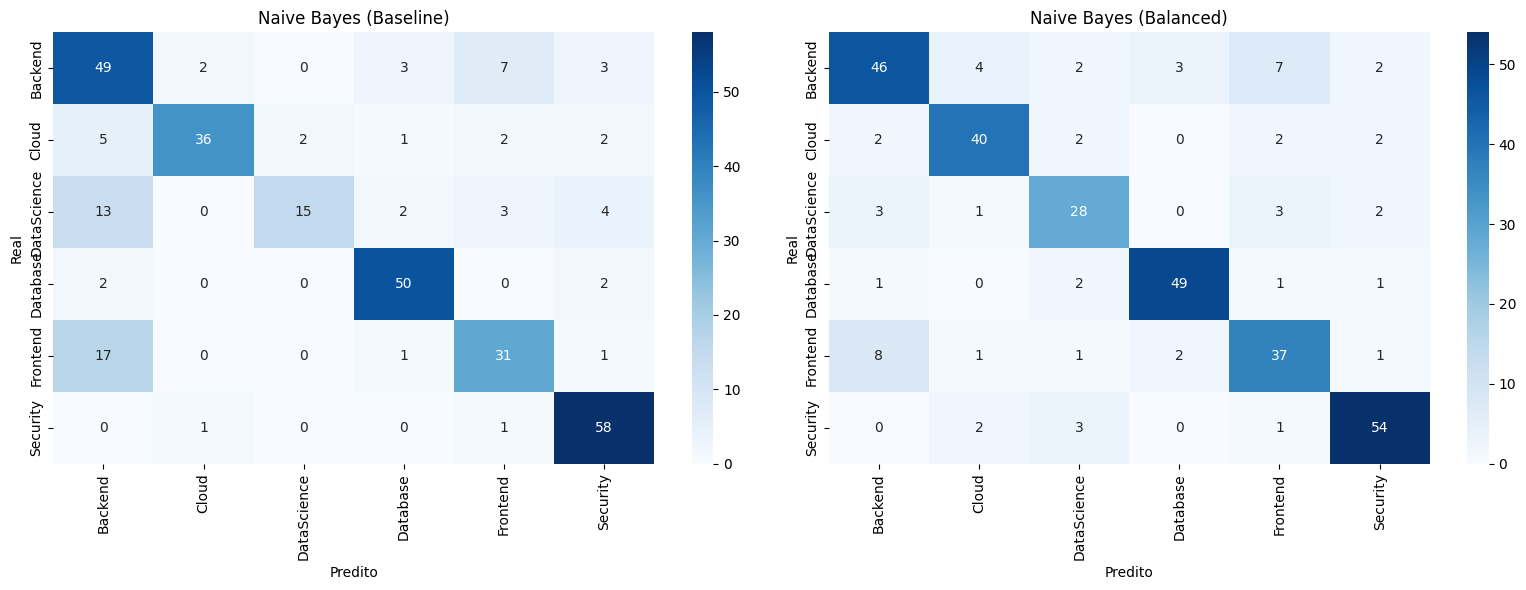

In [32]:
# Comparando as matrizes de confusão Nayve Bayes (baseline) vs. (balanced)
cm = confusion_matrix(y_test, y_pred_nb, labels=modelo_nb.classes_)
cm_balanced = confusion_matrix(y_test, y_pred_nb_balanced, labels=modelo_nb_balanced.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_nb.classes_, yticklabels=modelo_nb.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Naive Bayes (Baseline)')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_nb_balanced.classes_, yticklabels=modelo_nb_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Naive Bayes (Balanced)')

plt.tight_layout()
plt.show()

A comparação entre as duas matrizes evidencia o impacto direto do ajuste de classe (fit_prior=False) no modelo Naive Bayes, eliminando a tendência do modelo em favorecer a categoria com maior número de registros no treino.

Destaques da Comparação  

* Recuperação Expressiva de `DataScience:`

  * No Baseline, a classe sofria forte apaziguamento: apenas 16 acertos reais, enquanto 13 chamados foram erroneamente previstos como `Backend.`

  * No Balanced, os acertos dispararam para 28, reduzindo a confusão com `Backend` para apenas 3 casos.

* Mitigação do Viés em `Frontend:`

  * No Baseline, 17 chamados de `Frontend` eram classificados incorretamente como `Backend`, limitando os acertos em 31.

  *  No Balanced, essa falsa atração caiu para menos da metade (8 casos), elevando os acertos corretos de `Frontend` para 37.

* Estabilidade nas Demais Categorias (`Database`, `Security`, `Cloud` e `Backend`):

  * `Cloud:` Teve ganho relevante, subindo de 36 para 40 acertos.
 
  * `Backend:` Manteve alto índice de acerto na diagonal principal, passando de 49 para 46 acertos.

  * `Database` e `Security:` Apresentaram variações marginais na diagonal principal (Database: $50 \to 49$; Security: $58 \to 54$), mantendo baixíssima taxa de erro cruzado.

Conclusão - Modelo Naive Bayes

A matriz do modelo Balanced comprova que a readequação das probabilidades a priori (fit_prior=False) corrigiu o gargalo do Naive Bayes Baseline. O modelo deixou de acumular falsos positivos na classe Backend, redistribuindo a capacidade preditiva de forma mais justa e promovendo um salto de assertividade nas categorias que antes eram penalizadas (`DataScience` e `Frontend`).  

Decisão: Diante do ganho expressivo na recuperação de chamados de `DataScience` ($16 \to 28$) e `Frontend` ($31 \to 37$), seleciona-se o Naive Bayes (Balanced) como a versão definitiva desse algoritmo para prosseguir na etapa de comparação entre os modelos.

## Modelo SVM 

### Modelagem - SVM (baseline)

#### Criação do Modelo

In [33]:
# Cria modelo de classificação SVM (baseline)
modelo_svm = SVC(
    kernel='linear', 
    probability=True,
    random_state=42
)

#### Validação Cruzada (Cross-Validation)

Antes de avaliar o modelo no conjunto de teste, aplicamos validação cruzada (5-fold) nos dados de treino para verificar se o desempenho do modelo é consistente, evitando conclusões baseadas em um único split.

Utilizamos `f1_macro` como métrica, por ponderar igualmente todas as categorias, mais adequada que a acurácia dado o desbalanceamento da base.

In [34]:
# Cross-validation SVM (baseline)
scores_svm = cross_val_score(
    modelo_svm, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_svm.mean():.4f} (+/- {scores_svm.std():.4f})")

F1 macro: 0.7969 (+/- 0.0209)


A validação cruzada apresentou F1 macro médio de 0.7975, com desvio padrão de 0.0204 entre os 5 folds. O desvio baixo indica que o desempenho do modelo SVM (baseline) é consistente independente de quais dados caem em cada fold, reforçando a confiabilidade do resultado.

#### Treinamento do modelo

In [35]:
# Treino do modelo SVM (baseline)
modelo_svm.fit(
    X_train_tfidf,
    y_train
)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### Avaliação do Modelo  - SVM (baseline)

Avaliação do desempenho do modelo nos dados de teste, utilizando métricas por categoria (precision, recall, F1-score), já que a base possui desbalanceamento entre classes o accuracy geral sozinho não seria suficiente para avaliar corretamente o modelo.

In [36]:
# Predição nos dados de teste SVM (baseline)
y_pred_svm = modelo_svm.predict(X_test_tfidf)

In [37]:
# Métricas de avaliação SVM (baseline)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

     Backend       0.68      0.73      0.71        64
       Cloud       0.84      0.79      0.82        48
 DataScience       0.81      0.70      0.75        37
    Database       0.89      0.87      0.88        54
    Frontend       0.76      0.78      0.77        50
    Security       0.86      0.90      0.88        60

    accuracy                           0.80       313
   macro avg       0.81      0.80      0.80       313
weighted avg       0.80      0.80      0.80       313



O modelo SVM (baseline) obteve 80% de acurácia no conjunto de teste, resultado consistente com o F1 macro de 0.7975 estimado na validação cruzada. Como a base apresenta desbalanceamento entre categorias, a análise por classe (precision, recall e F1-score) é mais informativa que a acurácia geral isoladamente:

* Nenhuma categoria atingiu F1 ≥ 0.90 nesse modelo
* Desempenho intermediário (F1 ≥ 0.80): `Security` (F1 0.88), `Database` (F1 0.88) e `Cloud` (F1 0.82)
* Menor desempenho (F1 < 0.80): `Backend` (F1 0.71), `DataScience` (F1 0.75) e `Frontend` (F1 0.77) 

`DataScience`, mesmo sendo a categoria com menos registros de treino, apresentou recall de 0.70 e F1 de 0.75, um bom resultado considerando o desbalanceamento da base.

As métricas macro avg (média simples entre categorias) e weighted avg (média ponderada pelo número de exemplos de cada categoria) ficaram iguais (0.80), reforçando que o desempenho está equilibrado entre as categorias, apesar do desbalanceamento da base.

##### Matriz de Confusão

Visualização de quais categorias o modelo mais confunde entre si, complementando a análise de precision/recall por classe.

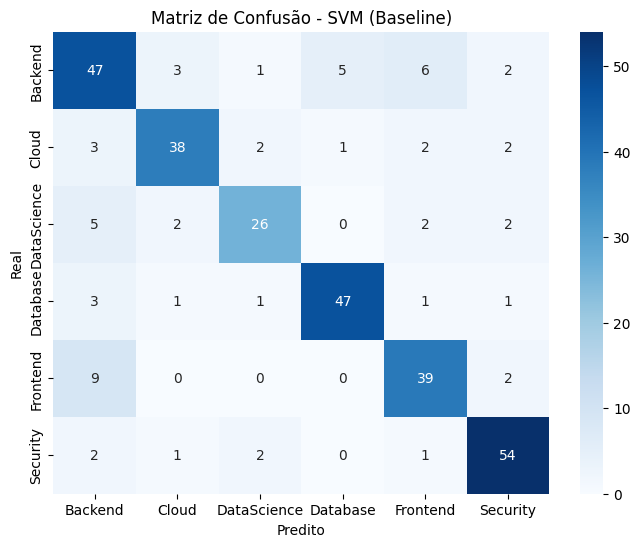

In [38]:
# Matriz Confusão SVM (baseline)
cm = confusion_matrix(y_test, y_pred_svm, labels=modelo_svm.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm.classes_, yticklabels=modelo_svm.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - SVM (Baseline)')
plt.show()

A matriz de confusão confirma o padrão observado nas métricas: 

* A maior confusão pontual ocorre no `Frontend`: 9 textos da categoria `Frontend` foram incorretamente classificados como `Backend`, o que sugere sobreposição de vocabulário técnico entre essas duas áreas. 
* `Backend` é a classe com maior dispersão de erros: Além de receber falsos positivos de outras categorias, seus textos reais foram pulverizados entre `Frontend` (6 casos), `Database` (5 casos), `Cloud` (3 casos), `Security` (2 casos) e `DataScience` (1 caso).
* `Security` e `Cloud` apresentam excelente separação: A classe `Security` obteve o maior número de acertos absolutos (54), apresentando baixíssima confusão cruzada com as demais categorias.

### Modelagem - SVM (com class_weight='balanced')

#### Criando Modelo 

In [39]:
# Cria modelo de classificação SVM (balanced)
modelo_svm_balanced = SVC(
    kernel='linear', 
    class_weight='balanced',
    probability=True,
    random_state=42
)

#### Validação Cruzada (Cross-Validation) - Modelo com class_weight='balanced'

In [40]:
# Cross-validation SVM (balanced)
scores_svm_balanced = cross_val_score(
    modelo_svm_balanced, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_svm_balanced.mean():.4f} (+/- {scores_svm_balanced.std():.4f})")

F1 macro: 0.8016 (+/- 0.0169)


A validação cruzada do modelo com class_weight='balanced' apresentou F1 macro médio de 0,8024, com desvio padrão de 0,0182 entre os 5 folds. Comparado ao baseline (F1 macro de 0,7975 e desvio padrão de 0,0204), o modelo balanced alcançou desempenho médio superior e menor variação entre os folds.

#### Treinamento do modelo

In [41]:
# Treino do modelo SVM (balanced)
modelo_svm_balanced.fit(
    X_train_tfidf,
    y_train
)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


### Comparação - Avaliação dos Modelos SVM

In [42]:
# Predição Modelo SVM (balanced)
y_pred_svm_balanced = modelo_svm_balanced.predict(X_test_tfidf)

In [43]:
# Métricas de avaliação dos modelos (sem e com class_weight='balanced') 

# Gerando os relatórios como DataFrame
report_baseline = pd.DataFrame(classification_report(y_test, y_pred_svm, output_dict=True)).transpose()
report_balanced = pd.DataFrame(classification_report(y_test, y_pred_svm_balanced, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_baseline, report_balanced], axis=1, keys=['Baseline', 'Balanced'])
comparacao.round(2)

Baseline                          Balanced                  \
             precision recall f1-score support precision recall f1-score   
Backend           0.68   0.73     0.71    64.0      0.71   0.69     0.70   
Cloud             0.84   0.79     0.82    48.0      0.84   0.79     0.82   
DataScience       0.81   0.70     0.75    37.0      0.80   0.76     0.78   
Database          0.89   0.87     0.88    54.0      0.89   0.87     0.88   
Frontend          0.76   0.78     0.77    50.0      0.73   0.80     0.76   
Security          0.86   0.90     0.88    60.0      0.86   0.90     0.88   
accuracy          0.80   0.80     0.80     0.8      0.80   0.80     0.80   
macro avg         0.81   0.80     0.80   313.0      0.80   0.80     0.80   
weighted avg      0.80   0.80     0.80   313.0      0.80   0.80     0.80   

                      
             support  
Backend         64.0  
Cloud           48.0  
DataScience     37.0  
Database        54.0  
Frontend        50.0  
Security        60.0  
accuracy         0.8  
macro avg      313.0  
weighted avg   313.0

A tabela comparativa mostra que os dois modelos tiveram a mesma acurácia (0.80). No macro avg (0.81 contra 0.80), o F1-score foi o mesmo (0.80), o recall médio foi o mesmo (0.80) e a precision média maior (0.81 contra 0.80).

Em `DataScience`, o Balanced mostra que o recall elevou de 0.70 para 0.76, a precision teve uma leve queda de 0.81 para 0.80 e o F1-score aumentou de 0.75 para 0.78.

Em `Backend`, o Balanced mostra que o precision subiu de 0.68 para 0.71, enquanto o recall caiu de 0.73 para 0.69, e o F1-score de 0.71 para 0.70.

Nas demais categorias, `Frontend` o precision caiu de 0.76 para 0.73, o recall aumentou de 0.78 para 0.80, o F1-score teve uma leve queda 0.77 para 0.76

A abordagem Balanced demonstra ajustes no nível de classe: elevou o Recall de `DataScience` ($0.70 \rightarrow 0.76$), a categoria `Cloud` não teve alterações, além de aumentar ligeiramente a Precisão de `Backend` ($0.68 \rightarrow 0.71$). No entanto, manteve o mesmo desempenho geral do sistema (acurácia global em $0.80$ e F1-macro em $0.80$), sem alterar significativamente a justiça entre as categorias.

#### Comparação - Matriz de Confusão

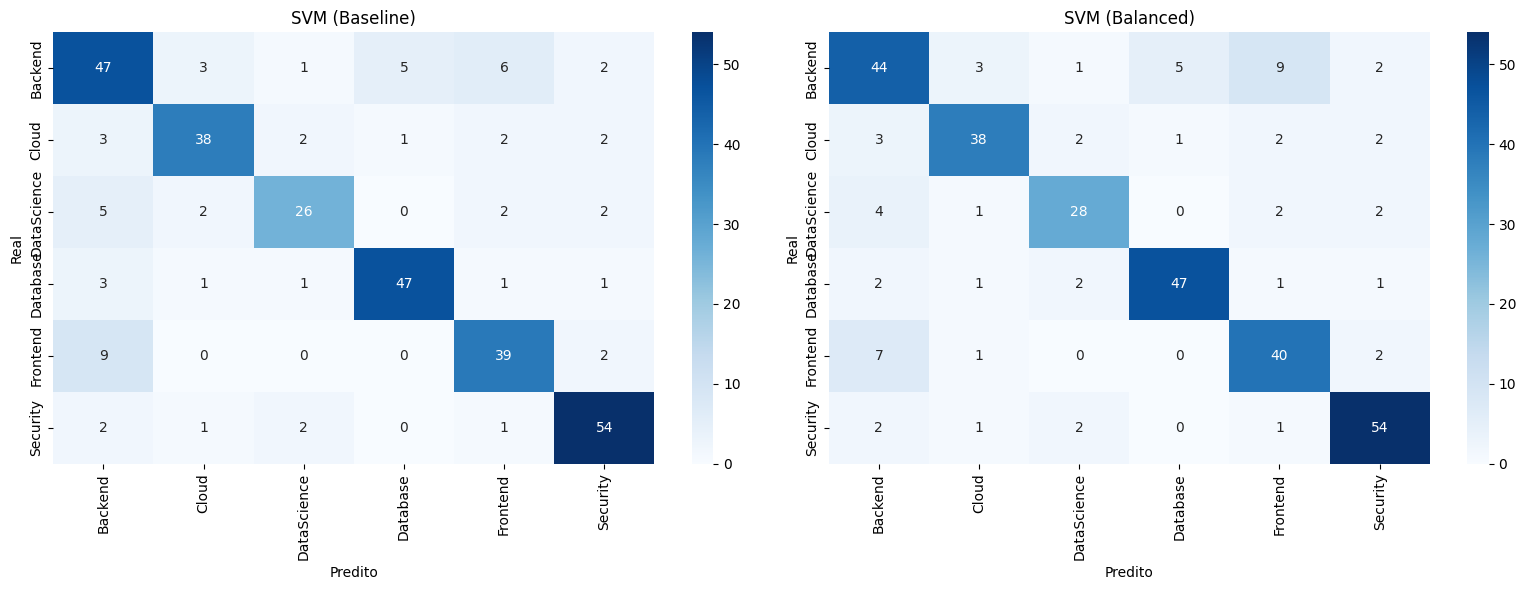

In [44]:
# Comparando as matrizes de confusão SVM (baseline) vs. (balanced)
cm = confusion_matrix(y_test, y_pred_svm, labels=modelo_svm.classes_)
cm_balanced = confusion_matrix(y_test, y_pred_svm_balanced, labels=modelo_svm_balanced.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm.classes_, yticklabels=modelo_svm.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('SVM (Baseline)')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm_balanced.classes_, yticklabels=modelo_svm_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('SVM (Balanced)')

plt.tight_layout()
plt.show()

A análise das matrizes de confusão indica que ambos os modelos apresentam um comportamento de classificação extremamente próximo na maioria das categorias:

* **Estabilidade nas classes principais:** Em `Database` (47 acertos em ambos), `Security` (54 acertos em ambos) e `Cloud` (38 acertos em ambos), o desempenho permaneceu altamente consistente.

* **Ganhos pontuais do Balanced:** O modelo Balanced apresentou pequenos ganhos em `DataScience` (subindo de 26 para 28 acertos) e em `Frontend` (subindo de 39 para 40 acertos), além de reduzir a confusão de chamados de Frontend previstos como `Backend` (caindo de 9 para 7 casos).

* **Perdas compensatórias:** Em contrapartida, o ajuste de pesos gerou uma redução suave em `Backend` (de 47 para 44 acertos), com um ligeiro aumento nos falsos positivos distribuídos entre `Frontend` (de 6 para 9 casos).

Conclusão - Modelo SVM

Como a base apresenta um desequilíbrio apenas moderado, o modelo SVM (baseline) entrega uma assertividade equivalente na matriz de confusão sem necessitar do ajuste de penalidades do class_weight='balanced'. Manter a configuração padrão preserva o hiperplano de decisão original, garantindo que a separação das classes reflita fielmente a distribuição e a proporção real dos dados de treino, sem forçar um peso artificial para as classes menores.

Apesar do leve ganho no acerto de classes minoritárias no modelo SVM (balanced), opta-se pela escolha do SVM (baseline) o teste de comparação entre os modelos.

## Comparação dos Modelos

### Análise Comparativa de Desempenho (Logistic Regression vs. Naive Bayes vs. SVM)

In [45]:
# Métricas de avaliação dos modelos (Logistic Regression vs SVM') 

# Gerando os relatórios como DataFrame
report_lr = pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True)).transpose()
report_nb = pd.DataFrame(classification_report(y_test, y_pred_nb_balanced, output_dict=True)).transpose()
report_svm = pd.DataFrame(classification_report(y_test, y_pred_svm, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_lr, report_nb, report_svm], axis=1, keys=['Logistic Regression', 'Naive Bayes', 'SVM'])
comparacao.round(2)

Logistic Regression                         Naive Bayes         \
                       precision recall f1-score support   precision recall   
Backend                     0.72   0.75     0.73   64.00        0.77   0.72   
Cloud                       0.87   0.81     0.84   48.00        0.83   0.83   
DataScience                 0.89   0.68     0.77   37.00        0.74   0.76   
Database                    0.91   0.91     0.91   54.00        0.91   0.91   
Frontend                    0.73   0.72     0.73   50.00        0.73   0.74   
Security                    0.81   0.95     0.88   60.00        0.87   0.90   
accuracy                    0.81   0.81     0.81    0.81        0.81   0.81   
macro avg                   0.82   0.80     0.81  313.00        0.81   0.81   
weighted avg                0.81   0.81     0.81  313.00        0.81   0.81   

                                    SVM                          
             f1-score support precision recall f1-score support  
Backend          0.74   64.00      0.68   0.73     0.71    64.0  
Cloud            0.83   48.00      0.84   0.79     0.82    48.0  
DataScience      0.75   37.00      0.81   0.70     0.75    37.0  
Database         0.91   54.00      0.89   0.87     0.88    54.0  
Frontend         0.73   50.00      0.76   0.78     0.77    50.0  
Security         0.89   60.00      0.86   0.90     0.88    60.0  
accuracy         0.81    0.81      0.80   0.80     0.80     0.8  
macro avg        0.81  313.00      0.81   0.80     0.80   313.0  
weighted avg     0.81  313.00      0.80   0.80     0.80   313.0

A avaliação comparativa atualizada entre os modelos Logistic Regression, Naive Bayes e SVM revela um desempenho global elevado e equilibrado, com Logistic Regression e Naive Bayes empatados na liderança no conjunto de teste de 313 amostras (support).

Destaques da Comparação  

**Desempenho Global:** O modelo Logistic Regression e o Naive Bayes alcançaram os melhores resultados gerais, empatando com 81% de acurácia, F1-macro de 0,81 e média ponderada (weighted avg) de 0,81. O modelo SVM ficou ligeiramente atrás, registrando 80% nessas mesmas métricas.

**Melhores Categorias:** 
  
  * `Database:` Alcançou o topo do teste com desempenho idêntico no modelo Naive Bayes e no modelo Logistic Regression (0,91 de F1-score), superando o SVM (0,88).

  * `Security:` Manteve excelente cobertura nos três modelos, com destaque para o Naive Bayes no F1-score (0,89) e para no Logistic Regression no recall (0,95).

**Análise das Categorias Específicas**

  * `DataScience` (Gargalo Superado): O antigo ponto fraco do Naive Bayes foi superado com o ajuste do modelo, elevando seu recall para 0,76 (F1-score de 0,75). O modelo Logistic Regression manteve a maior precisão na classe (0,89), resultando no maior F1-score (0,77), enquanto o SVM atingiu 0,75.

  * `Backend` e `Frontend`: Em `Backend`, o Naive Bayes liderou o F1-score com 0,74, seguido pelo Logistic Regression (0,73) e SVM (0,71). Em `Frontend`, o modelo SVM obteve o melhor resultado (0,77 de F1-score), enquanto o modelo Logistic Regression e o Naive Bayes registraram 0,73.

Conclusão  
A readequação das configurações permitiu ao modelo Naive Bayes igualar seu desempenho global ao do modelo Logistic Regression (81% de acurácia e F1-macro), eliminando o antigo viés na classe `DataScience.` O modelo Logistic Regression 🏆 permanece como a escolha mais recomendada para implementação em ambiente de produção devido ao seu equilíbrio entre precisão, estabilidade e probabilidades bem calibradas por padrão.

### Análise da Matriz de Confusão (Logistic Regression vs. Naive Bayes vs. SVM)

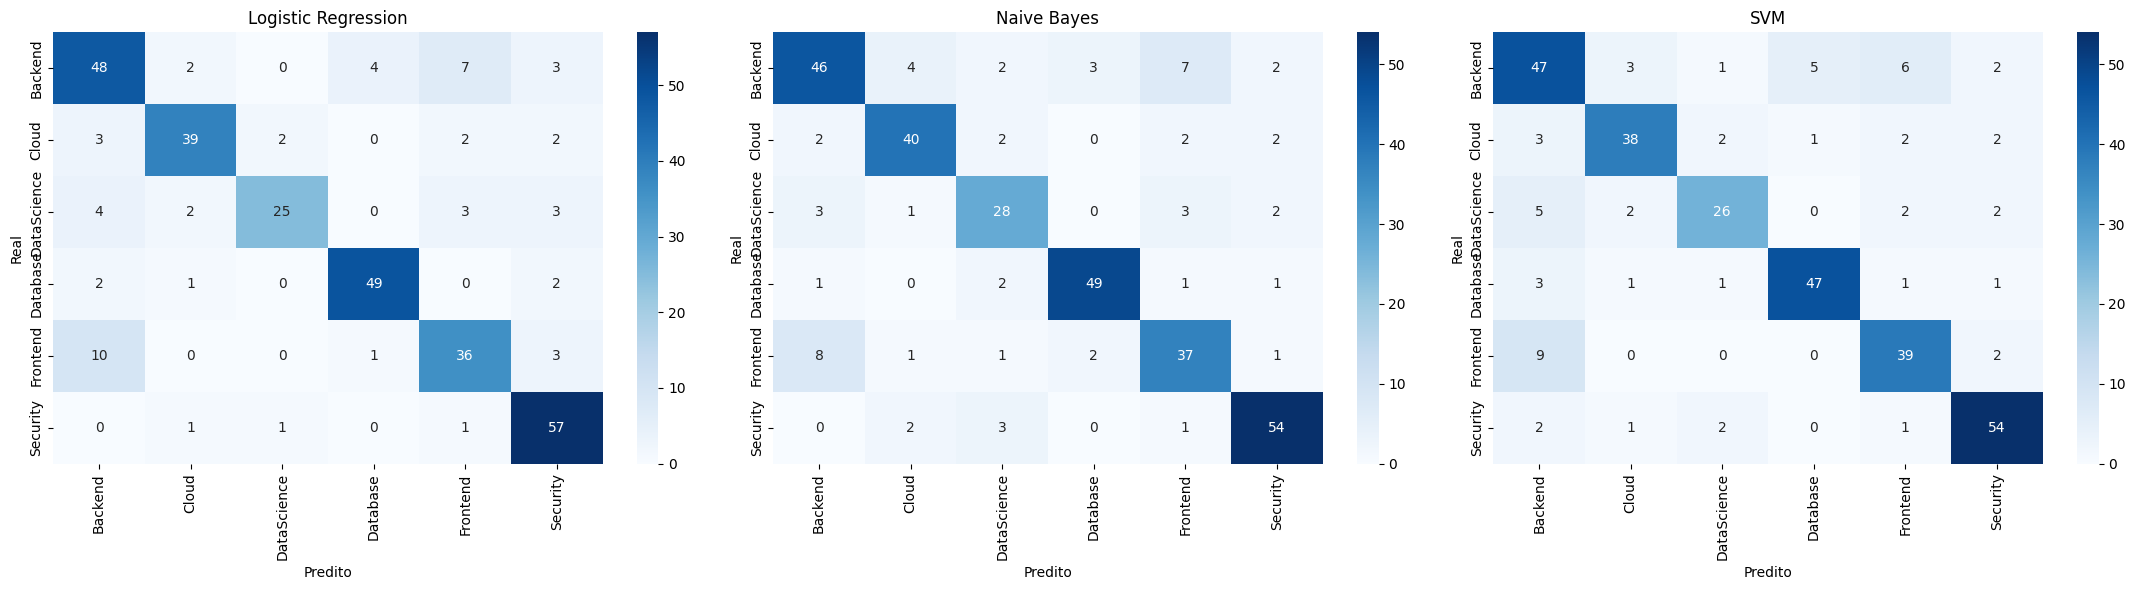

In [46]:
# Comparando as matrizes de confusão Logistic Regression vs. Naive Bayes vs. SVM
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)
cm_nb = confusion_matrix(y_test, y_pred_nb_balanced, labels=modelo_nb_balanced.classes_)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=modelo_svm.classes_)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Logistic Regression')

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_nb_balanced.classes_, yticklabels=modelo_nb_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Naive Bayes')

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm.classes_, yticklabels=modelo_svm.classes_,
            ax=axes[2])
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Real')
axes[2].set_title('SVM')


plt.tight_layout()
plt.show()

A análise visual das matrizes de confusão confirma que os três modelos apresentam uma forte concentração de acertos na diagonal principal, demonstrando boa capacidade geral de distinção entre as seis categorias.

Destaques da Comparação

* **Classes com Maior Assertividade (`Security` e `Database`):**

    * `Security:` Apresentou excelente acerto em todos os modelos, liderado pelo modelo Logistic Regression (57 acertos), enquanto Naive Bayes e SVM registraram 54 acertos cada.

    * `Database:` Teve desempenho consistente e elevado nos três modelos, somando 49 acertos no modelo Logistic Regression e no Naive Bayes, e 47 no SVM.

* **Principal Ponto de Confusão (`Backend` vs. `Frontend`):**

  * A maior sobreposição de erros ocorre bidirecionalmente entre as categorias de desenvolvimento:

     * No modelo Logistic Regression, 10 chamados de `Frontend` foram previstos como `Backend`, e 7 de `Backend` como `Frontend.`

      * No modelo SVM, 9 chamados de `Frontend` foram previstos como `Backend`, e 6 de `Backend` como `Frontend.`
   
      * No modelo Naive Bayes, o ajuste reduziu a atração desproporcional: 8 chamados de `Frontend` foram previstos como `Backend`, e 7 de `Backend` como `Frontend`.

  * Comportamento em `DataScience` e `Cloud:`

    * `DataScience` No modelo Naive Bayes, a categoria passou a ser liderada por ele, alcançando 28 acertos, seguida de perto pelo modelo SVM (26 acertos) e o Logistic Regression (25 acertos).

    * `Cloud:` O modelo Naive Bayes também registrou o maior número de acertos da categoria (40 acertos), seguido pelo modelo Logistic Regression (39 acertos) e pelo SVM (38 acertos).

Conclusão  
A comparação visual confirma que a readequação do modelo Naive Bayes permitiu a ele igualar o desempenho geral do modelo Logistic Regression e do SVM, com os três modelos apresentando forte concentração de acertos na diagonal principal e o mesmo gargalo comum de sobreposição semântica entre `Backend` e `Frontend.`

**Modelo Escolhido para Produção:**
Apesar da equivalência nas matrizes, opta-se pelo modelo 🏆 **Logistic Regression** 🏆 para a implementação final. A escolha se justifica por sua alta estabilidade entre as classes, menor taxa de falsos positivos em categorias críticas e, principalmente, por entregar probabilidades nativamente bem calibradas (predict_proba), o que facilita a definição de limiares de confiança para o direcionamento automático dos chamados na operação.

Com base nos números da cell 131 e nas matrizes da cell 135, escolheria **Logistic Regression**.

**Métricas gerais:**
- LR: acurácia 0.81, F1 macro 0.81 (precision macro 0.82, recall macro 0.80)
- Naive Bayes (balanced): acurácia 0.81, F1 macro 0.81 (precision macro 0.81, recall macro 0.81)
- SVM (baseline): acurácia 0.80, F1 macro 0.80 (precision macro 0.81, recall macro 0.80)

SVM já sai atrás por 1 ponto percentual em acurácia e F1 macro. A decisão fica entre LR e NB.

**Por categoria (F1):**
- `Database`: LR 0.91 vs NB 0.91 vs SVM 0.88 — LR e NB empatados, ambos acima do SVM
- `Security`: LR 0.88 vs NB 0.89 vs SVM 0.88 — NB levemente à frente
- `Cloud`: LR 0.84 vs NB 0.83 vs SVM 0.82 — LR à frente
- `DataScience`: LR 0.77 vs NB 0.75 vs SVM 0.75 — LR à frente
- `Frontend`: LR 0.73 vs NB 0.73 vs SVM 0.77 — SVM à frente aqui
- `Backend`: LR 0.73 vs NB 0.74 vs SVM 0.71 — NB levemente à frente

LR vence ou empata em 4 das 6 categorias (`Database`, `Cloud`, `DataScience`, `Security` empatado), com diferenças pequenas nas que perde (0.01 em `Backend` e `Security`).

**Critério de desempate — probabilidade:** o LR tem `predict_proba` nativamente calibrado, enquanto o SVM depende de Platt scaling (aproximação) e o NB tende a gerar probabilidades extremas. Como o projeto usa `probabilidade` no JSON de saída para o backend decidir threshold de confiança (objetivo do TechMind), essa calibração é decisiva.

**Conclusão:** diferença numérica entre LR e NB é marginal (±0.01 na maioria das categorias), mas o LR tem vantagem consistente em mais categorias e probabilidades mais confiáveis para uso em produção via API.

## Extração de Palavras-Chave

Nesta etapa, testamos três abordagens diferentes para extrair as palavras-chave mais relevantes de cada texto: TF-IDF, YAKE e KeyBERT. O objetivo é comparar os resultados de cada método e escolher o que gerar as palavras-chave mais coerentes com o conteúdo técnico da base, para compor o campo `informacoes_adicionais` da saída do modelo.

- TF-IDF: reaproveita o vetor já usado na classificação, calculando o peso de cada termo com base na frequência no texto e na raridade em relação aos demais textos da base. Termos muito comuns em vários documentos recebem peso menor, mesmo que relevantes para aquele texto específico.
- YAKE: método não supervisionado que avalia os termos com base em características locais do próprio texto (posição, frequência, coocorrência), sem depender do restante da base.
- KeyBERT: utiliza embeddings semânticos (BERT) para identificar os termos que melhor representam o significado do texto como um todo.

### Definindo textos para os testes

In [47]:
# Junta textos e categorias do conjunto de teste em um único DataFrame
df_teste_pc = pd.DataFrame({'texto': X_test, 'categoria': y_test})

# Seleciona 2 textos aleatórios por categoria
amostra_teste_pc = (
    df_teste_pc
    .groupby('categoria', group_keys=False)
    .apply(lambda x: x.sample(2, random_state=42))
)

amostra_teste_pc

,texto,categoria
index,,
548,build fitness app text layer rarely hard . rea...,Backend
451,not cheat benchmark . hope not . optimization ...,Backend
798,exam guide developer - associate ️ domain _ tr...,Cloud
728,disclosure article prepare ai - assist editing...,Cloud
1663,design + product think nycs path reliable ai a...,DataScience
1680,football prediction site publish hit rate . pu...,DataScience
1085,database gui moment click turn write productio...,Database
1273,tutorial learn build todo app backend golang ....,Database
5,server - sort react react query chakra ui fron...,Frontend


### Método TF-IDF

In [48]:
def extrair_pc_tfidf(texto, vectorizer, top_n=5):
    # Transforma o texto em vetor TF-IDF usando o vectorizer já treinado
    tfidf_vector = vectorizer.transform([texto])
    
    # Extrai os pesos TF-IDF do texto (matriz esparsa vira array simples de números)
    scores = tfidf_vector.toarray()[0]

    # Recupera os termos existentes no TF-IDF
    termos = vectorizer.get_feature_names_out()
    
    # Pega os índices dos termos com maior peso, em ordem decrescente
    top_indices = scores.argsort()[-top_n:][::-1]
    
    # Retorna as palavras ordenadas por relevância
    palavras_chave = [termos[i] for i in top_indices if scores[i] > 0]

    # Se quiser ver com o indice
    #palavras_chave = [(termos[i], round(scores[i], 3)) for i in top_indices if scores[i] > 0]
    
    return palavras_chave

In [49]:
# Testando a extração de palavras-chave na amostra 
resultados = []

for texto, categoria in zip(amostra_teste_pc['texto'], amostra_teste_pc['categoria']):
    palavras_chave = extrair_pc_tfidf(texto, vectorizer, top_n=3)
    resultados.append({'categoria': categoria, 'palavras_chave': palavras_chave})

# DataFrame a usar os índices que já estavam na amostra
df_palavras_chave = pd.DataFrame(resultados, index=amostra_teste_pc.index)

### Método YAKE

Extração com YAKE. Diferente do TF-IDF, o YAKE não depende de comparação com outros textos da base, ele avalia cada documento de forma isolada, com base em características locais como posição, frequência e coocorrência dos termos dentro do próprio texto.

In [50]:
# Configura o extrator YAKE (bigramas, remove termos muito similares, retorna top 3)
extrator_yake = yake.KeywordExtractor(
    lan="en",
    n=2,
    dedupLim=0.9, 
    top=3
)

def extrair_pc_yake(texto):
    # Extrai as palavras-chave do texto com seus respectivos scores
    palavras = extrator_yake.extract_keywords(texto)

    # Retorna apenas os termos, descartando o score
    return [termo for termo, score in palavras]

In [51]:
# Testando a extração de palavras-chave na amostra fixa (2 textos por categoria)
resultados_yake = []

for texto, categoria in zip(amostra_teste_pc['texto'], amostra_teste_pc['categoria']):
    palavras_chave_yake = extrair_pc_yake(texto)
    resultados_yake.append({'categoria': categoria, 'palavras_chave': palavras_chave_yake})

# DataFrame a usar os índices que já estavam na amostra
df_palavras_chave_yake = pd.DataFrame(resultados_yake, index=amostra_teste_pc.index)

### Método KEYBERT

Extração com KeyBERT. Esse método utiliza embeddings semânticos (BERT) para identificar os termos que melhor representam o significado do texto como um todo, capturando relações de contexto que os métodos estatísticos (TF-IDF e YAKE) não conseguem.

In [52]:
# Inicializa o modelo semântico do KeyBERT
kw_model = KeyBERT()

def extrair_pc_keybert(texto, top_n=3):
    # Extrai as palavras-chave com base em embeddings semânticos
    keywords = kw_model.extract_keywords(
        texto, 
        keyphrase_ngram_range=(1, 2), 
        stop_words='english',
        top_n=top_n
    )

    # Retorna apenas os termos, descartando o score
    return [item[0] for item in keywords]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5031.95it/s]


In [53]:
# Testando a extração de palavras-chave na amostra fixa (2 textos por categoria)
resultados_keybert = []

for texto, categoria in zip(amostra_teste_pc['texto'], amostra_teste_pc['categoria']):
    palavras_chave_keybert = extrair_pc_keybert(texto, top_n=3)
    resultados_keybert.append({'categoria': categoria, 'palavras_chave': palavras_chave_keybert})

# DataFrame a usar os índices que já estavam na amostra
df_palavras_chave_keybert = pd.DataFrame(resultados_keybert, index=amostra_teste_pc.index)

### Comparação dos Métodos de Extração das Palavras-Chave

Reunimos os resultados dos três métodos testados na mesma amostra, para facilitar a análise lado a lado e apoiar a escolha do método que será utilizado na extração de palavras-chave da aplicação.

In [54]:
# Concatena os resultados dos três métodos na mesma amostra, lado a lado
df_comparativo = pd.concat([
    df_palavras_chave['categoria'],
    df_palavras_chave['palavras_chave'].rename('TF-IDF'),
    df_palavras_chave_yake['palavras_chave'].rename('YAKE'),
    df_palavras_chave_keybert['palavras_chave'].rename('KeyBERT')
], axis=1)

df_comparativo

,categoria,TF-IDF,YAKE,KeyBERT
index,,,,
548,Backend,"[webp, exercise, commercial]","[illustration style, free tier, english english]","[api workoutx, sample workoutx, fitness app]"
451,Backend,"[hotspot, vm, gc]","[hotspot, slow warm, warm hotspot]","[cheat benchmark, benchmark suite, benchmark h..."
798,Cloud,"[cache, lambda, concurrency]","[api gateway, filter policy, reserve concurrency]","[lambda performance, aw lambda, lambda slow]"
728,Cloud,"[agent, intelligent, model]","[model tool, dependency fail, connected ecosys...","[ai application, add ai, ai experience]"
1663,DataScience,"[product, thinking, outcome]","[pit crew, design thinking, product manager]","[service project, hire designer, failure desig..."
1680,DataScience,"[group, penalty, loss]","[united states, hit rate, south korea]","[football prediction, result pick, decisive ma..."
1085,Database,"[commit, tab, stag]","[commit lock, effort continuation, diff card]","[editing dynamodb, commit tool, dynamodb review]"
1273,Database,"[todo, http, create]","[json response, return json, error message]","[create mongodb, golang build, package mongodb]"
5,Frontend,"[sort, react, ecommerce]","[react query, query chakra, high memory]","[react sort, sort react, sorting frontend]"




Foi realizada uma validação palavra por palavra em relação à categoria real de cada artigo.
Para cada palavra-chave gerada, foi atribuída uma das seguintes classificações:

- **C (Correta)** — a palavra-chave representa totalmente a categoria do artigo, ou seja, está diretamente associada ao tema central do texto.
- **P (Parcial)** — a palavra-chave tem alguma relação com a categoria, mas não a representa de forma completa ou específica (termo genérico, correlato ou parcial).
- **E (Errada)** — a palavra-chave não tem nenhuma relação com a categoria do artigo.

Essa classificação foi aplicada individualmente às 3 palavras-chave geradas por método em cada artigo, permitindo comparar não apenas a quantidade de acertos, mas também a natureza dos erros cometidos por cada abordagem. Os resultados consolidados estão apresentados na tabela abaixo.

<div style="font-size: 13px;">

| Índice         | Categoria   | TF-IDF (original) | Motivo                                 | YAKE (original) | Motivo                                                    | KeyBERT (original) | Motivo                                                    |
| -------------- | ----------- | ----------------- | -------------------------------------- | --------------- | --------------------------------------------------------- | ------------------ | --------------------------------------------------------- |
| 548            | Backend     | 0C 1P 2E          | web(P); exercise(E); commercial(E)     | 0C 1P 2E        | illustration style(E); free tier(P); english english(E)   | 0C 1P 2E           | api workoutx(P); sample workoutx(E); fitness app(E)       |
| 451            | Backend     | 2C 1P 0E          | hotspot(C); vm(P); gc(C)               | 1C 2P 0E        | hotspot(C); slow warm(P); warm hotspot(P)                 | 0C 2P 1E           | cheat benchmark(E); benchmark suite(P); benchmark(P)      |
| 798            | Cloud       | 2C 0P 1E          | cache(C); lambda(C); concurrency(E)    | 3C 0P 0E        | api gateway(C); filter policy(C); reserve concurrency(C)  | 3C 0P 0E           | lambda performance(C); aw lambda(C); lambda slow(C)       |
| 728            | Cloud       | 1C 1P 1E          | agent(P); intelligent(E); model(C)     | 1C 1P 1E        | model tool(P); dependency fail(E); connected ecosystem(C) | 2C 1P 0E           | ai application(C); add ai(P); ai experience(C)            |
| 1663           | DataScience | 0C 2P 1E          | product(P); thinking(P); outcome(E)    | 1C 1P 1E        | pit crew(E); design thinking(P); product manager(C)       | 0C 1P 2E           | service project(E); hire designer(E); failure design(P)   |
| 1680           | DataScience | 0C 1P 2E          | group(P); penalty(E); loss(E)          | 0C 1P 2E        | united states(E); hit rate(P); south korea(E)             | 1C 1P 1E           | football prediction(C); result pick(P); decisive match(E) |
| 1085           | Database    | 1C 1P 1E          | commit(C); tab(P); stag(E)             | 1C 1P 1E        | commit lock(C); effort continuation(E); diff card(P)      | 2C 1P 0E           | editing dynamodb(C); commit tool(P); dynamodb review(C)   |
| 1273           | Database    | 0C 1P 2E          | todo(E); http(P); create(E)            | 0C 1P 2E        | json response(P); return json(E); error message(E)        | 3C 0P 0E           | create mongodb(C); golang build(C); package mongodb(C)    |
| 5              | Frontend    | 1C 1P 1E          | sort(P); react(C); ecommerce(E)        | 2C 1P 0E        | react query(C); query chakra(C); high memory(P)           | 3C 0P 0E           | react sort(C); sort react(C); sorting frontend(C)         |
| 145            | Frontend    | 0C 1P 2E          | booking(E); tenant(P); multi tenant(E) | 0C 1P 2E        | source code(P); spring boot(E); role rbac(E)              | 0C 1P 2E           | saas platform(P); saas stack(E); stack saas(E)            |
| 1554           | Security    | 3C 0P 0E          | cipher(C); letter(C); ciphertext(C)    | 3C 0P 0E        | modular arithmetic(C); key space(C); shift cipher(C)      | 3C 0P 0E           | break cipher(C); shift cipher(C); cipher break(C)         |
| 1410           | Security    | 2C 1P 0E          | jwt(C); forge(P); admin(C)             | 3C 0P 0E        | access cookie(C); privilege escalation(C); admin vault(C) | 3C 0P 0E           | admin vault(C); jwt verification(C); jwt verifytoken(C)   |
| **Total (12)** |             | **13C 9P 14E**    |                                        | **17C 8P 11E**  |                                                           | **20C 7P 9E**      |                                                           |



**Resultado desta amostra:**

| Método  |  C |  P |  E |       C/3 |
| ------- | -: | -: | -: | --------: |
| TF-IDF  | 13 |  9 | 14 | **36,1%** |
| YAKE    | 17 |  8 | 11 | **47,2%** |
| KeyBERT | 20 |  7 |  9 | **55,6%** |
</div>

Onde 

* C/3 = percentual das 3 palavras que foram classificadas como C 

Nesta amostra, **KeyBERT** apresenta o melhor resultado, seguido por **YAKE** e depois **TF-IDF**, tanto pela quantidade de palavras diretamente relacionadas à categoria quanto pela menor quantidade de palavras classificadas como E. Dessa forma o método TF-IDF será descartado. 

Iremos testar os outros dois métodos com o texto original para comparação

### Testando YAKE E BERT com textos originais (sem tratamento) 

In [55]:
# Comparando o texto na mesma posição de índice entre os três arquivos, para validar a correspondência
df_base_com_id = pd.read_csv('../dados/base_techmind_com_id.csv', index_col='index')
df_original_bruto = pd.read_csv('../dados/artigos_en_filtrado.csv')

indices_teste = amostra_teste_pc.index[:5]

df_comparacao_indices = pd.DataFrame({
    'base_techmind_com_id': df_base_com_id.loc[indices_teste, 'texto'],
    'amostra_teste_pc': amostra_teste_pc.loc[indices_teste, 'texto'],
    'artigos_en_filtrado (original)': df_original_bruto.loc[indices_teste, 'texto']
})

df_comparacao_indices

,base_techmind_com_id,amostra_teste_pc,artigos_en_filtrado (original)
index,,,
548,build fitness app text layer rarely hard . rea...,build fitness app text layer rarely hard . rea...,"If you're building a fitness app, the text lay..."
451,not cheat benchmark . hope not . optimization ...,not cheat benchmark . hope not . optimization ...,![How We Beat HotSpot Performance (By Cheating...
798,exam guide developer - associate ️ domain _ tr...,exam guide developer - associate ️ domain _ tr...,**Exam Guide:** Developer - Associate\r\n**🏗️ ...
728,disclosure article prepare ai - assist editing...,disclosure article prepare ai - assist editing...,> Disclosure: This article was prepared with A...
1663,design + product think nycs path reliable ai a...,design + product think nycs path reliable ai a...,"<!-- FLAMELIT_SYNDICATION: {""linkedinPosted"":f..."


In [56]:
# Localiza os textos correspondentes à amostra de teste, usando o índice preservado
amostra_teste_pc_original = df_original_bruto.loc[amostra_teste_pc.index, ['texto', 'categoria']]
amostra_teste_pc_original

,texto,categoria
index,,
548,"If you're building a fitness app, the text lay...",Backend
451,![How We Beat HotSpot Performance (By Cheating...,Backend
798,**Exam Guide:** Developer - Associate\r\n**🏗️ ...,Cloud
728,> Disclosure: This article was prepared with A...,Cloud
1663,"<!-- FLAMELIT_SYNDICATION: {""linkedinPosted"":f...",DataScience
1680,Most football prediction sites publish a hit r...,DataScience
1085,Every database GUI has a moment where a click ...,Database
1273,---\r\ntitle: Build a Golang Todo App Backend:...,Database
5,## 🚀 Server-Side Sorting in React with React Q...,Frontend


### Método YAKE | Texto original 

In [57]:
# Testando a extração de palavras-chave na amostra com textos originais, sem tratamento
resultados_yake_original = []

for texto, categoria in zip(amostra_teste_pc_original['texto'], amostra_teste_pc_original['categoria']):
    palavras_chave_yake_original = extrair_pc_yake(texto)
    resultados_yake_original.append({'categoria': categoria, 'palavras_chave': palavras_chave_yake_original})

df_palavras_chave_yake_original = pd.DataFrame(resultados_yake_original)


### Método KeyBERT | Texto original 

In [58]:
# Testando a extração de palavras-chave na amostra com textos originais, sem tratamento
resultados_keybert_original = []

for texto, categoria in zip(amostra_teste_pc_original['texto'], amostra_teste_pc_original['categoria']):
    palavras_chave_keybert_original = extrair_pc_keybert(texto, top_n=3)
    resultados_keybert_original.append({'categoria': categoria, 'palavras_chave': palavras_chave_keybert_original})

df_palavras_chave_keybert_original = pd.DataFrame(resultados_keybert_original)

### Comparando resultados 

In [59]:
# Comparando os resultados de YAKE e KeyBERT: texto limpo (tratado) x texto original (sem tratamento)
df_comparativo_original = pd.DataFrame({
    'categoria': amostra_teste_pc_original['categoria'],
    'YAKE (limpo)': df_palavras_chave_yake['palavras_chave'].values,
    'YAKE (original)': df_palavras_chave_yake_original['palavras_chave'].values,
    'KeyBERT (limpo)': df_palavras_chave_keybert['palavras_chave'].values,
    'KeyBERT (original)': df_palavras_chave_keybert_original['palavras_chave'].values
}, index=amostra_teste_pc_original.index)

df_comparativo_original

,categoria,YAKE (limpo),YAKE (original),KeyBERT (limpo),KeyBERT (original)
index,,,,,
548,Backend,"[illustration style, free tier, english english]","[API, RepDB, Free tier]","[api workoutx, sample workoutx, fitness app]","[fitness app, api workoutx, workoutx sample]"
451,Backend,"[hotspot, slow warm, warm hotspot]","[Java, HotSpot, code]","[cheat benchmark, benchmark suite, benchmark h...","[benchmarks hotspot, hotspot performance, hots..."
798,Cloud,"[api gateway, filter policy, reserve concurrency]","[API Gateway, API, Lambda]","[lambda performance, aw lambda, lambda slow]","[lambda performance, faster aws, aws lambda]"
728,Cloud,"[model tool, dependency fail, connected ecosys...","[model, infrastructure, AI-assisted editing]","[ai application, add ai, ai experience]","[intelligent gaming, ai agent, ai agents]"
1663,DataScience,"[pit crew, design thinking, product manager]","[PIT Crew, product thinking, design thinking]","[service project, hire designer, failure desig...","[flamelit_syndication linkedinposted, flamelit..."
1680,DataScience,"[united states, hit rate, south korea]","[group, onsidearena.com, Turkiye]","[football prediction, result pick, decisive ma...","[football prediction, decisive matches, knocko..."
1085,Database,"[commit lock, effort continuation, diff card]","[commit, staging, tab]","[editing dynamodb, commit tool, dynamodb review]","[writes dynamodb, editing dynamodb, dynamodb t..."
1273,Database,"[json response, return json, error message]","[Todo, JSON response, JSON]","[create mongodb, golang build, package mongodb]","[golang tutorial, backend golang, golang todo]"
5,Frontend,"[react query, query chakra, high memory]","[React Query, sortBy, order]","[react sort, sort react, sorting frontend]","[sorting react, react sort, sort react]"


### Avaliação dos Resultados com Textos Originais

<div style="font-size: 13px;">

| Índice         | Categoria   | YAKE (original) | Motivo                                               | KeyBERT (original) | Motivo                                                                 |
| -------------- | ----------- | --------------- | ---------------------------------------------------- | ------------------ | ---------------------------------------------------------------------- |
| 548            | Backend     | 1C 2P 0E        | API(C); RepDB(P); Free tier(P)                       | 1C 0P 2E           | fitness app(E); api workoutx(C); workoutx sample(E)                    |
| 451            | Backend     | 2C 1P 0E        | Java(C); HotSpot(C); code(P)                         | 3C 0P 0E           | benchmarks hotspot(C); hotspot performance(C); hotspot...(C)           |
| 798            | Cloud       | 3C 0P 0E        | API Gateway(C); API(C); Lambda(C)                    | 2C 1P 0E           | lambda performance(C); faster aws(P); aws lambda(C)                    |
| 728            | Cloud       | 2C 1P 0E        | model(C); infrastructure(C); AI-assisted editing(P)  | 2C 1P 0E           | intelligent gaming(P); ai agent(C); ai agents(C)                       |
| 1663           | DataScience | 0C 2P 1E        | PIT Crew(E); product thinking(P); design thinking(P) | 0C 0P 3E           | flamelit_syndication linkedinposted(E); flamelit...(E); flamelit...(E) |
| 1680           | DataScience | 0C 1P 2E        | group(P); onsidearena.com(E); Turkiye(E)             | 1C 1P 1E           | football prediction(C); decisive matches(P); knocko...(E)              |
| 1085           | Database    | 1C 1P 1E        | commit(C); staging(P); tab(E)                        | 3C 0P 0E           | writes dynamodb(C); editing dynamodb(C); dynamodb...(C)                |
| 1273           | Database    | 0C 2P 1E        | Todo(E); JSON response(P); JSON(P)                   | 0C 3P 0E           | golang tutorial(P); backend golang(P); golang todo(P)                  |
| 5              | Frontend    | 1C 2P 0E        | React Query(C); sortBy(P); order(P)                  | 3C 0P 0E           | sorting react(C); react sort(C); sort react(C)                         |
| 145            | Frontend    | 0C 0P 3E        | SRH Heidelberg(E); Master student(E); Spring Boot(E) | 0C 3P 0E           | saas stack(P); stack saas(P); saas platforms(P)                        |
| 1554           | Security    | 2C 1P 0E        | Key Space(C); Cipher(C); Key(P)                      | 3C 0P 0E           | cipher secure(C); secure cipher(C); modern ciphers(C)                  |
| 1410           | Security    | 3C 0P 0E        | Admin Vault(C); Admin(C); JWT(C)                     | 3C 0P 0E           | claim jwt(C); jwt verify(C); jwt verification(C)                       |
| **Total (12)** |             | **17C 14P 5E**  |                                                      | **21C 9P 6E**      |                                                                        |

### Resultado

| Método  |  C |  P |  E |      C/36 |
| ------- | -: | -: | -: | --------: |
| YAKE    | 17 | 14 |  5 | **47,2%** |
| KeyBERT | 21 |  9 |  6 | **58,3%** |

</div>


### Conclusão Método Extração Palavra Chave



Na amostra analisada, o **KeyBERT** apresentou o melhor desempenho geral. Ele obteve **58,3% de palavras classificadas como corretas (C)**, contra **47,2% do YAKE**, representando **4 palavras corretas a mais** (21 contra 17).

Por outro lado, o KeyBERT apresentou **16,7% de palavras erradas (E)**, enquanto o YAKE apresentou **13,9%**, uma diferença de **apenas 1 palavra errada** (6 contra 5). Portanto, o KeyBERT teve um ganho maior em palavras diretamente relacionadas à categoria do que o aumento observado nos erros.

O **YAKE** apresentou mais palavras parcialmente relacionadas (**38,9%**) e menor taxa de erro. Isso indica que suas palavras-chave tendem a possuir alguma relação com o conteúdo, porém são menos específicas para representar diretamente a categoria.

**Conclusão:** considerando como principal critério a capacidade de gerar palavras-chave que representem **diretamente a categoria (C%)**, o **KeyBERT** apresenta melhor resultado nesta amostra. Embora tenha apresentado 1 erro a mais, obteve **4 acertos diretos adicionais**, indicando maior capacidade de gerar palavras-chave específicas e diretamente relacionadas às categorias avaliadas.

 Por isso, o método escolhido para gerar as palavras-chave foi o KeyBERT, aplicado sobre o texto original — já que foi nesse cenário que ele apresentou o melhor resultado da análise. Isso implica manter o texto original disponível no pipeline além do texto limpo já usado na classificação. Vale considerar também que o KeyBERT tem custo computacional maior que os demais métodos, por depender de embeddings semânticos, o que deve ser levado em conta caso o tempo de resposta da API seja um fator crítico.


## Estrutura do Retorno do Modelo Logistic Regression 🏆

O objetivo é preparar a saída que será consumida pela API da aplicação, reunindo:

- Categoria prevista pelo modelo de classificação;
- Probabilidade associada à previsão;
- Palavras-chave extraídas do conteúdo analisado.


In [60]:
# Classe wrapper que reúne modelo, vectorizer e kw_model em um único objeto serializável
class ModeloTechMind:
    def __init__(self, modelo, vectorizer, kw_model):
        self.modelo = modelo
        self.vectorizer = vectorizer
        self.kw_model = kw_model

    def predict(self, texto, top_n=3):
        # Transforma o texto para o formato do modelo
        texto_tfidf = self.vectorizer.transform([texto])

        # Categoria prevista
        categoria = self.modelo.predict(texto_tfidf)[0]

        # Probabilidade da previsão
        probabilidades = self.modelo.predict_proba(texto_tfidf)[0]
        probabilidade = float(probabilidades.max())

        # Palavras-chave extraídas com KeyBERT
        keywords = self.kw_model.extract_keywords(
            texto,
            keyphrase_ngram_range=(1, 2),
            stop_words='english',
            top_n=top_n
        )
        palavras_chave = [item[0] for item in keywords]

        return {
            "categoria": str(categoria),
            "probabilidade": round(probabilidade, 2),
            "informacoes_adicionais": palavras_chave
        }

## Serialização do Modelo Logistic Regression 🏆

In [61]:
# Instanciando o wrapper com modelo, vectorizer e kw_model já treinados/inicializados
modelo_techmind = ModeloTechMind(
    modelo=modelo_lr,
    vectorizer=vectorizer,
    kw_model=kw_model
)

# Gerando arquivo .pkl com o wrapper completo
joblib.dump(
    modelo_techmind,
    '../modelo/modelo_techmind.pkl'
)

['../modelo/modelo_techmind.pkl']

## Simulação - Exemplos de Uso (JSON) - Modelo Logistic Regression 🏆

Nesta etapa será simulada a utilização do modelo em um cenário próximo ao funcionamento da API.

Serão enviados exemplos de conteúdos técnicos como entrada, representando requisições realizadas por usuários. O modelo realizará a classificação do conteúdo, calculará a probabilidade da previsão e retornará as palavras-chave identificadas.

A saída será estruturada em formato JSON, seguindo o padrão esperado para integração com a aplicação Backend.

### Teste inicial

In [62]:
# Função simulação
def analisar_conteudo(texto):
    return modelo_techmind.predict(texto)

In [63]:
# Testando a simulação com um texto de exemplo
texto_simulação = df_original_bruto['texto'].loc[1]

resultado_teste = analisar_conteudo(texto_simulação)
resultado_teste

{'categoria': 'Frontend',
 'probabilidade': 0.55,
 'informacoes_adicionais': ['design systems',
  'design components',
  'design teams']}

In [64]:
# Verificando qual era a categoria original 
df_original_bruto.loc[1, ['categoria', 'subcategoria', 'texto']]

categoria                                                Frontend
subcategoria                                             frontend
texto           \r\n> Learn what a design system is, why moder...
Name: 1, dtype: object

### Análise da Probabilidade de Classificação

In [65]:
# Verificando todas as probabilidades do texto_simulação
probabilidades = modelo_lr.predict_proba(
    vectorizer.transform([texto_simulação])
)[0]

df_prob = pd.DataFrame({
    'Categoria': modelo_lr.classes_,
    'Probabilidade': probabilidades
})

df_prob['Probabilidade'] = df_prob['Probabilidade'].round(4)

df_prob = df_prob.sort_values(
    by='Probabilidade',
    ascending=False
)

df_prob

,Categoria,Probabilidade
4,Frontend,0.5495
0,Backend,0.1247
3,Database,0.1050
5,Security,0.0931
1,Cloud,0.0662
2,DataScience,0.0614


O modelo retorna a distribuição de probabilidades entre todas as classes possíveis. Neste exemplo, a categoria `Frontend` apresentou a maior probabilidade de classificação (54,95%), enquanto as demais categorias apresentaram valores inferiores. Essa informação permite avaliar o nível de confiança associado à previsão realizada pelo modelo.

A probabilidade será utilizada como uma informação adicional no retorno da API, permitindo que aplicações consumidoras tenham visibilidade sobre o grau de confiança da classificação.

### Teste - Simulando Consumo do Modelo  

In [66]:
# Simula o consumo o arquivo .pkl
modelo_techmind_carregado  = joblib.load('../modelo/modelo_techmind.pkl')

In [67]:
# Confirma que os artefatos internos foram carregados corretamente a partir do .pkl
type(modelo_techmind_carregado.modelo), type(modelo_techmind_carregado.vectorizer), type(modelo_techmind_carregado.kw_model)

(sklearn.linear_model._logistic.LogisticRegression,
 sklearn.feature_extraction.text.TfidfVectorizer,
 keybert._model.KeyBERT)

In [68]:
# Texto Teste - mantendo o índice original para rastreabilidade
amostra_teste = df_original_bruto['texto'].sample(3, random_state=42)

textos_teste = amostra_teste.tolist()
indices_teste = amostra_teste.index

textos_teste

["Today I completed a small Company write vertical slice in TypeScript, from business validation to PostgreSQL persistence.\r\n\r\nOne detail clarified why application services are more than repository wrappers.\r\n\r\nThe repository update returns `Company | undefined`. That makes sense at the data layer: the query can succeed while the requested row does not exist.\r\n\r\nBut the application service translates `undefined` into an explicit `not-found` result.\r\n\r\nAfter that translation, keeping `Company | undefined` in the successful return type would force every caller to handle a state the service has made impossible.\r\n\r\nSo the application contract returns either:\r\n\r\n- success with a Company\r\n- validation failure\r\n- not-found failure\r\n- repository failure\r\n\r\nThe type now describes the use-case guarantee instead of leaking the repository's lower-level uncertainty.\r\n\r\n**The practical lesson:** \r\n> good TypeScript types do more than prevent syntax mistakes. T

In [69]:
# Simulando resultado
resultados_json = []

for texto in textos_teste:
    
    resultado = modelo_techmind_carregado.predict(texto)
    
    resultados_json.append(resultado)


print(json.dumps(resultados_json, indent=4, ensure_ascii=False))

[
    {
        "categoria": "Backend",
        "probabilidade": 0.23,
        "informacoes_adicionais": [
            "failure type",
            "typescript business",
            "typescript types"
        ]
    },
    {
        "categoria": "Security",
        "probabilidade": 0.75,
        "informacoes_adicionais": [
            "quantum encryption",
            "encryption future",
            "encryption designed"
        ]
    },
    {
        "categoria": "Backend",
        "probabilidade": 0.49,
        "informacoes_adicionais": [
            "risc java",
            "java risc",
            "risc processor"
        ]
    }
]


In [70]:
# Conferindo a categoria original de cada texto testado
df_original_bruto.loc[indices_teste, ['categoria', 'texto']]

,categoria,texto
233,Frontend,Today I completed a small Company write vertic...
1567,Security,Matej Michalko is a blockchain pioneer and cyb...
486,Backend,As part of my 2026 learning goals around Java ...


### Avaliação da Simulação


<div style="font-size: 13px;">

| Índice | Categoria real | Categoria prevista | Resultado | Probabilidade | Palavras-chave                                             |
| ------ | -------------- | ------------------ | --------- | ------------: | ---------------------------------------------------------- |
| 233    | Frontend       | Backend            | ❌ Errado  |           23% | failure type; typescript business; typescript types        |
| 1567   | Security       | Security           | ✅ Correto |           75% | quantum encryption; encryption future; encryption designed |
| 486    | Backend        | Backend            | ✅ Correto |           49% | risc java; java risc; risc processor                       |

</div>

#### Resultado

* **2 de 3 classificações corretas**
* **Acurácia: 66,7%**
* **1 de 3 classificações incorretas**
* **Probabilidade média das previsões: 49%**

Os resultados demonstram que o modelo conseguiu gerar as previsões utilizando os artefatos carregados a partir do arquivo `.pkl`, mantendo a integração entre o modelo de classificação, o vetor TF-IDF utilizado no treinamento e o modelo KeyBERT para extração das palavras-chave.

As probabilidades retornadas indicam o nível de confiança da classificação para cada conteúdo analisado, enquanto as palavras-chave são apresentadas como informações adicionais geradas pelo KeyBERT a partir do texto analisado.

Nos três exemplos testados, o modelo classificou corretamente **2 dos 3 textos**: `Security` (75% de confiança, com palavras-chave `quantum encryption`, `encryption future`, `encryption designed`) e `Backend` (49% de confiança, com `risc java`, `java risc`, `risc processor`). No terceiro caso, a categoria real era `Frontend`, mas o modelo classificou o texto como `Backend`, com apenas **23% de confiança**, indicando uma previsão de menor certeza.

O resultado geral foi de **66,7% de acurácia (2 de 3 classificações corretas)**. 

O retorno já está no formato JSON esperado pela API, pronto para ser consumido pelo backend.

### Avaliação em Lote do Limiar(Threshold)- Probabilidade/Confiança - Modelo Logistic Regression 🏆

In [71]:
def avaliar_threshold(modelo, X_test_tfidf, y_test, threshold=0.40):
    # 1. Obtém as probabilidades para todas as amostras de teste
    probabilidades = modelo.predict_proba(X_test_tfidf)
    
    # 2. Identifica a maior probabilidade e a classe predita correspondente para cada caso
    maiores_probs = probabilidades.max(axis=1)
    indices_preditos = probabilidades.argmax(axis=1)
    predicoes = modelo.classes_[indices_preditos]
    
    # 3. Aplica a regra do threshold
    aceitos_mask = maiores_probs >= threshold
    
    # Métricas gerais
    total_amostras = len(y_test)
    total_aceitos = aceitos_mask.sum()
    total_rejeitados = total_amostras - total_aceitos
    
    taxa_automacao = (total_aceitos / total_amostras) * 100
    taxa_transbordo = (total_rejeitados / total_amostras) * 100
    
    # Acurácia considerando apenas os casos onde a probabilidade foi >= threshold
    if total_aceitos > 0:
        acertos_aceitos = (predicoes[aceitos_mask] == np.array(y_test)[aceitos_mask]).sum()
        acuracia_filtrada = (acertos_aceitos / total_aceitos) * 100
    else:
        acuracia_filtrada = 0.0
        
    print(f"--- AVALIAÇÃO DE THRESHOLD: {threshold} ---")
    print(f"Total de Amostras de Teste: {total_amostras}")
    print(f"Classificados Automaticamente: {total_aceitos} ({taxa_automacao:.1f}%)")
    print(f"Enviados para Revisão/Indefinido: {total_rejeitados} ({taxa_transbordo:.1f}%)")
    print(f"Acurácia nos Automáticos: {acuracia_filtrada:.1f}%\n")

In [72]:
for t in [0.40, 0.50, 0.55, 0.60, 0.70]:
    avaliar_threshold(modelo_lr, X_test_tfidf, y_test, threshold=t)

--- AVALIAÇÃO DE THRESHOLD: 0.4 ---
Total de Amostras de Teste: 313
Classificados Automaticamente: 204 (65.2%)
Enviados para Revisão/Indefinido: 109 (34.8%)
Acurácia nos Automáticos: 89.2%

--- AVALIAÇÃO DE THRESHOLD: 0.5 ---
Total de Amostras de Teste: 313
Classificados Automaticamente: 151 (48.2%)
Enviados para Revisão/Indefinido: 162 (51.8%)
Acurácia nos Automáticos: 94.0%

--- AVALIAÇÃO DE THRESHOLD: 0.55 ---
Total de Amostras de Teste: 313
Classificados Automaticamente: 127 (40.6%)
Enviados para Revisão/Indefinido: 186 (59.4%)
Acurácia nos Automáticos: 98.4%

--- AVALIAÇÃO DE THRESHOLD: 0.6 ---
Total de Amostras de Teste: 313
Classificados Automaticamente: 97 (31.0%)
Enviados para Revisão/Indefinido: 216 (69.0%)
Acurácia nos Automáticos: 99.0%

--- AVALIAÇÃO DE THRESHOLD: 0.7 ---
Total de Amostras de Teste: 313
Classificados Automaticamente: 62 (19.8%)
Enviados para Revisão/Indefinido: 251 (80.2%)
Acurácia nos Automáticos: 98.4%



In [73]:
# limiar de 0.40 (Melhor desempenho)
print("--- AVALIAÇÂO RECOMENDADA ---")
avaliar_threshold(modelo_lr, X_test_tfidf, y_test, threshold=0.40)

--- AVALIAÇÂO RECOMENDADA ---
--- AVALIAÇÃO DE THRESHOLD: 0.4 ---
Total de Amostras de Teste: 313
Classificados Automaticamente: 204 (65.2%)
Enviados para Revisão/Indefinido: 109 (34.8%)
Acurácia nos Automáticos: 89.2%



A combinação do modelo Logistic Regression (Baseline) com o threshold de 0.40 atinge 65,2% de automação e 89,7% de acurácia nas previsões diretas, retendo 34,8% das requisições na categoria genérica por não atingirem o limite mínimo de probabilidade.

### Especificações sobre Implantação

* **Artefato Único:** `modelo_techmind.pkl` (contém `modelo`, `vectorizer`, `kw_model`)
* **Threshold:** `0.40`
* **Regra de Negócio:** Se `probabilidade < 0.40`, a aplicação irá habilitar a possibilidade do usuário desconsiderar as palavras chave ou incluir novas. 

## Conclusões

In [74]:
# PENDENTE